In [1]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import numpy.ma as ma
from scipy.stats import gaussian_kde

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
path='/content/drive/My Drive/Work7_MAUNet_Light_Data_Model_Result'

In [4]:
MAUNet_Test_Grid=np.load(path+'/Result/DailyGridded/Work7_MAUNet_TRMMIMD_TestResult.npy')
SRDRN_Test_Grid=np.load(path+'/Result/DailyGridded/Work7_SRDRN_TRMMIMD_TestResult.npy')
MAUNet_Light_KR_Test_Grid=np.load(path+'/Result/DailyGridded/Work7_MAUNet_Light_KR_TRMMIMD_TestResult.npy')
MAUNet_Light_GT_Test_Grid=np.load(path+'/Result/DailyGridded/Work7_MAUNet_Light_TrainWithGT_TRMMIMD_TestResult.npy')
MAUNet_Light_MP_Test_Grid=np.load(path+'/Result/DailyGridded/Work7_MAUNet_Light_TrainWithTeacherPred_TRMMIMD_TestResult.npy')
QDM_Test_Grid=np.load(path+'/Result/DailyGridded/Work7_QDM_TRMMIMD_TestResult.npy')
QM_Test_Grid=np.load(path+'/Result/DailyGridded/Work7_QM_TRMMIMD_TestResult.npy')
BiasData_Test_Grid=np.load(path+'/Result/DailyGridded/Work7_BiasData_Test_TRMMIMD.npy')
Label_Test_Grid=np.load(path+'/Result/DailyGridded/Work7_Label_Test_TRMMIMD.npy')

In [5]:
datamask=np.load(path+"/Data/Mask-TRMM128x128.npy")

In [6]:
testmask=[]
for i in range(len(Label_Test_Grid)):
  testmask.append(datamask)
testmask=np.array(testmask)

In [7]:
Masked_MAUNet_Test_Grid=ma.masked_array(MAUNet_Test_Grid, mask=testmask)
Masked_SRDRN_Test_Grid=ma.masked_array(SRDRN_Test_Grid, mask=testmask)
Masked_MAUNet_Light_GT_Test_Grid=ma.masked_array(MAUNet_Light_GT_Test_Grid, mask=testmask)
Masked_MAUNet_Light_MP_Test_Grid=ma.masked_array(MAUNet_Light_MP_Test_Grid, mask=testmask)
Masked_MAUNet_Light_KR_Test_Grid=ma.masked_array(MAUNet_Light_KR_Test_Grid, mask=testmask)
Masked_QDM_Test_Grid=ma.masked_array(QDM_Test_Grid, mask=testmask)
Masked_QM_Test_Grid=ma.masked_array(QM_Test_Grid, mask=testmask)
Masked_BiasData_Test_Grid=ma.masked_array(BiasData_Test_Grid, mask=testmask)
Masked_Label_Test_Grid=ma.masked_array(Label_Test_Grid, mask=testmask)

##Find PDF at each grid point and obtain KL-divergence

In [8]:
from scipy.stats import entropy
import statistics
def grid_pdf_cal(Actual,Predicted,datamask):
  KL_Divergence_grid=np.zeros((128,128))
  for i in range(128):
    for j in range(128):
      if datamask[i,j]==0:
        data_act=Actual[:,i,j]
        data_pred=Predicted[:,i,j]

        # Check if data has enough variation for KDE
        if statistics.stdev(data_act) > 0 and statistics.stdev(data_pred) > 0:
          kde_act = gaussian_kde(data_act)
          # Evaluate the PDF at specific points. Using the data points themselves as evaluation points.
          # Adding a small jitter to predicted data points to avoid identical values if they are constant but non-zero
          pdf_values_act = kde_act(data_act)

          kde_pred = gaussian_kde(data_pred)
          # Adding a small jitter to predicted data points to avoid identical values if they are constant but non-zero
          #pdf_values_pred = kde_pred(data_pred + np.random.normal(0, 1e-9, size=data_pred.shape))
          pdf_values_pred = kde_pred(data_pred)

          # Add a small epsilon to zero values in pdf_values_pred before computing entropy
          #epsilon = 1e-10
          #pdf_values_pred = np.maximum(pdf_values_pred, epsilon)
          #pdf_values_act = np.maximum(pdf_values_act, epsilon)

          KL_Divergence_grid[i][j] = entropy(pdf_values_act, pdf_values_pred)
        else:
          # Assign NaN or a specific value if data is constant
          KL_Divergence_grid[i][j] = np.nan # or some other indicator

  return KL_Divergence_grid

In [9]:
KL_MAUNet_Test_Grid=grid_pdf_cal(Label_Test_Grid,MAUNet_Test_Grid,datamask)
KL_SRDRN_Test_Grid=grid_pdf_cal(Label_Test_Grid,SRDRN_Test_Grid,datamask)
KL_MAUNet_Light_KR_Test_Grid=grid_pdf_cal(Label_Test_Grid,MAUNet_Light_KR_Test_Grid,datamask)
KL_MAUNet_Light_GT_Test_Grid=grid_pdf_cal(Label_Test_Grid,MAUNet_Light_GT_Test_Grid,datamask)
KL_MAUNet_Light_MP_Test_Grid=grid_pdf_cal(Label_Test_Grid,MAUNet_Light_MP_Test_Grid,datamask)
KL_QDM_Test_Grid=grid_pdf_cal(Label_Test_Grid,QDM_Test_Grid,datamask)
KL_QM_Test_Grid=grid_pdf_cal(Label_Test_Grid,QM_Test_Grid,datamask)
KL_BiasData_Test_Grid=grid_pdf_cal(Label_Test_Grid,BiasData_Test_Grid,datamask)

In [10]:
Masked_KL_MAUNet_Test_Grid=ma.masked_array(KL_MAUNet_Test_Grid, mask=datamask)
Masked_KL_SRDRN_Test_Grid=ma.masked_array(KL_SRDRN_Test_Grid, mask=datamask)
Masked_KL_MAUNet_Light_GT_Test_Grid=ma.masked_array(KL_MAUNet_Light_GT_Test_Grid, mask=datamask)
Masked_KL_MAUNet_Light_MP_Test_Grid=ma.masked_array(KL_MAUNet_Light_MP_Test_Grid, mask=datamask)
Masked_KL_MAUNet_Light_KR_Test_Grid=ma.masked_array(KL_MAUNet_Light_KR_Test_Grid, mask=datamask)
Masked_KL_QDM_Test_Grid=ma.masked_array(KL_QDM_Test_Grid, mask=datamask)
Masked_KL_QM_Test_Grid=ma.masked_array(KL_QM_Test_Grid, mask=datamask)
Masked_KL_BiasData_Test_Grid=ma.masked_array(KL_BiasData_Test_Grid, mask=datamask)

MAUNet: Mean KL Divergence = 0.1470


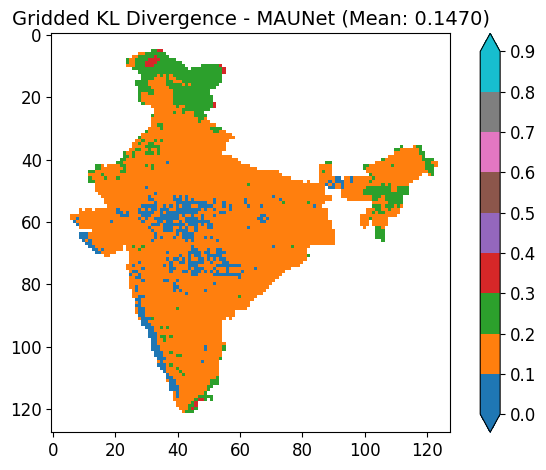

SRDRN: Mean KL Divergence = 0.1530


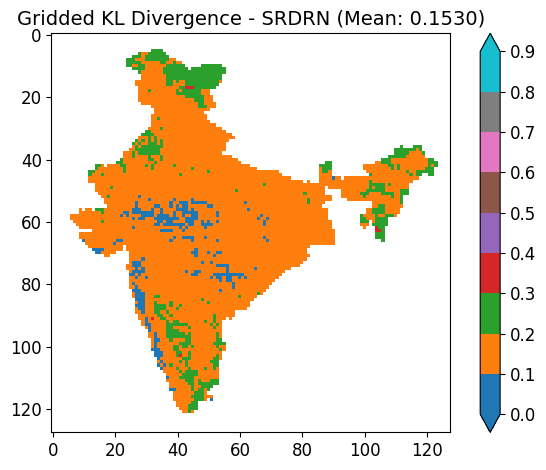

MAUNet_Light_GT: Mean KL Divergence = 0.1541


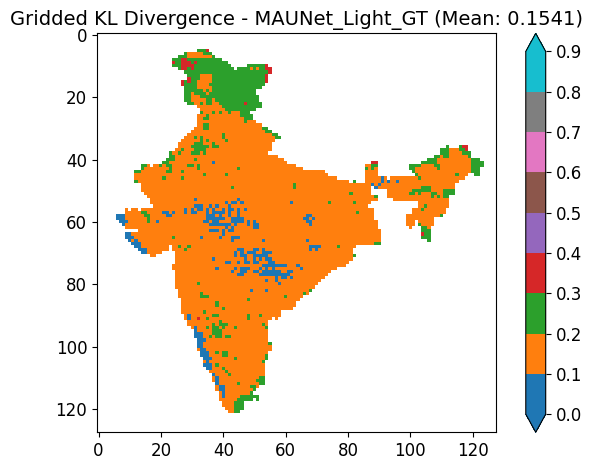

MAUNet_Light_MP: Mean KL Divergence = 0.1491


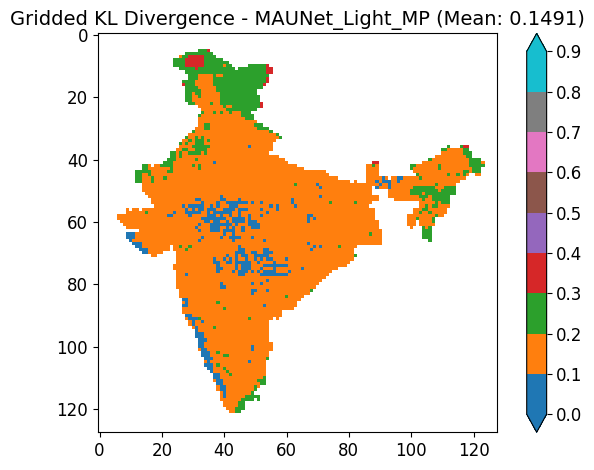

MAUNet_Light_KR: Mean KL Divergence = 0.1533


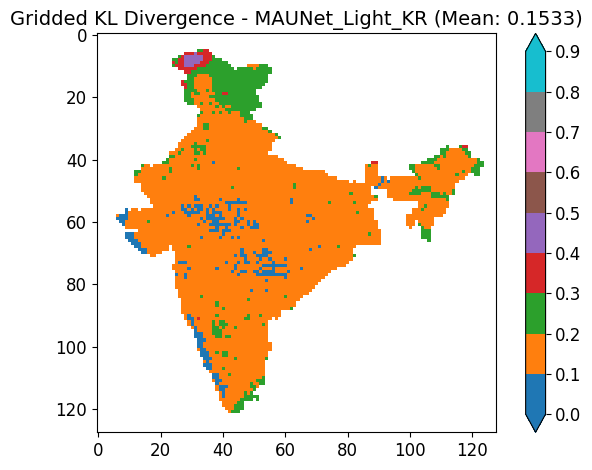

QDM: Mean KL Divergence = 0.1908


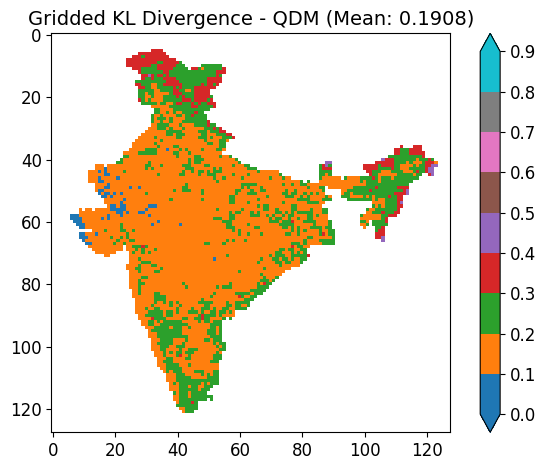

QM: Mean KL Divergence = 0.1879


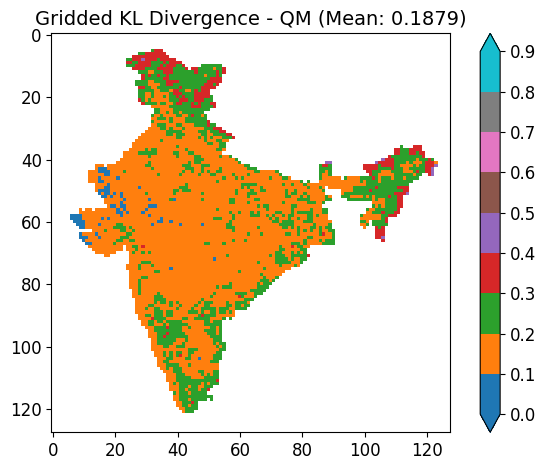

BiasData: Mean KL Divergence = 0.1984


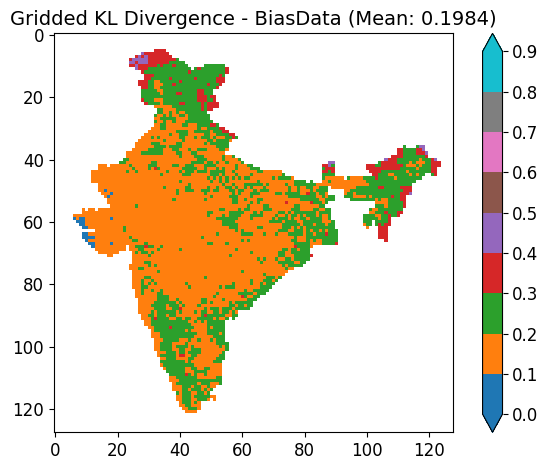

In [11]:
import matplotlib.pyplot as plt
import matplotlib as mpl
import numpy as np
import numpy.ma as ma

# --- Grids dictionary ---
kl_grids = {
    "MAUNet": Masked_KL_MAUNet_Test_Grid,
    "SRDRN": Masked_KL_SRDRN_Test_Grid,
    "MAUNet_Light_GT": Masked_KL_MAUNet_Light_GT_Test_Grid,
    "MAUNet_Light_MP": Masked_KL_MAUNet_Light_MP_Test_Grid,
    "MAUNet_Light_KR": Masked_KL_MAUNet_Light_KR_Test_Grid,
    "QDM": Masked_KL_QDM_Test_Grid,
    "QM": Masked_KL_QM_Test_Grid,
    "BiasData": Masked_KL_BiasData_Test_Grid
}

# --- Colormap and normalization ---
cmap = plt.colormaps["tab10"]
bounds = [0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]
norm = mpl.colors.BoundaryNorm(bounds, cmap.N)

# --- Plot each model ---
for model_name, masked_array in kl_grids.items():
    # Extract unmasked and non-NaN values
    unmasked_values = masked_array[~masked_array.mask]
    unmasked_values = unmasked_values[~np.isnan(unmasked_values)]
    mean_value = np.mean(unmasked_values)

    print(f"{model_name}: Mean KL Divergence = {mean_value:.4f}")

    fig, ax = plt.subplots()
    im = ax.imshow(masked_array, cmap=cmap, norm=norm)

    ax.tick_params(axis='x', labelsize=12)
    ax.tick_params(axis='y', labelsize=12)

    cbar = fig.colorbar(im, ax=ax, orientation="vertical", extend='both')
    cbar.ax.tick_params(labelsize=12)

    # Title
    ax.set_title(f"Gridded KL Divergence - {model_name} (Mean: {mean_value:.4f})", fontsize=14)

    plt.tight_layout()
    plt.show()


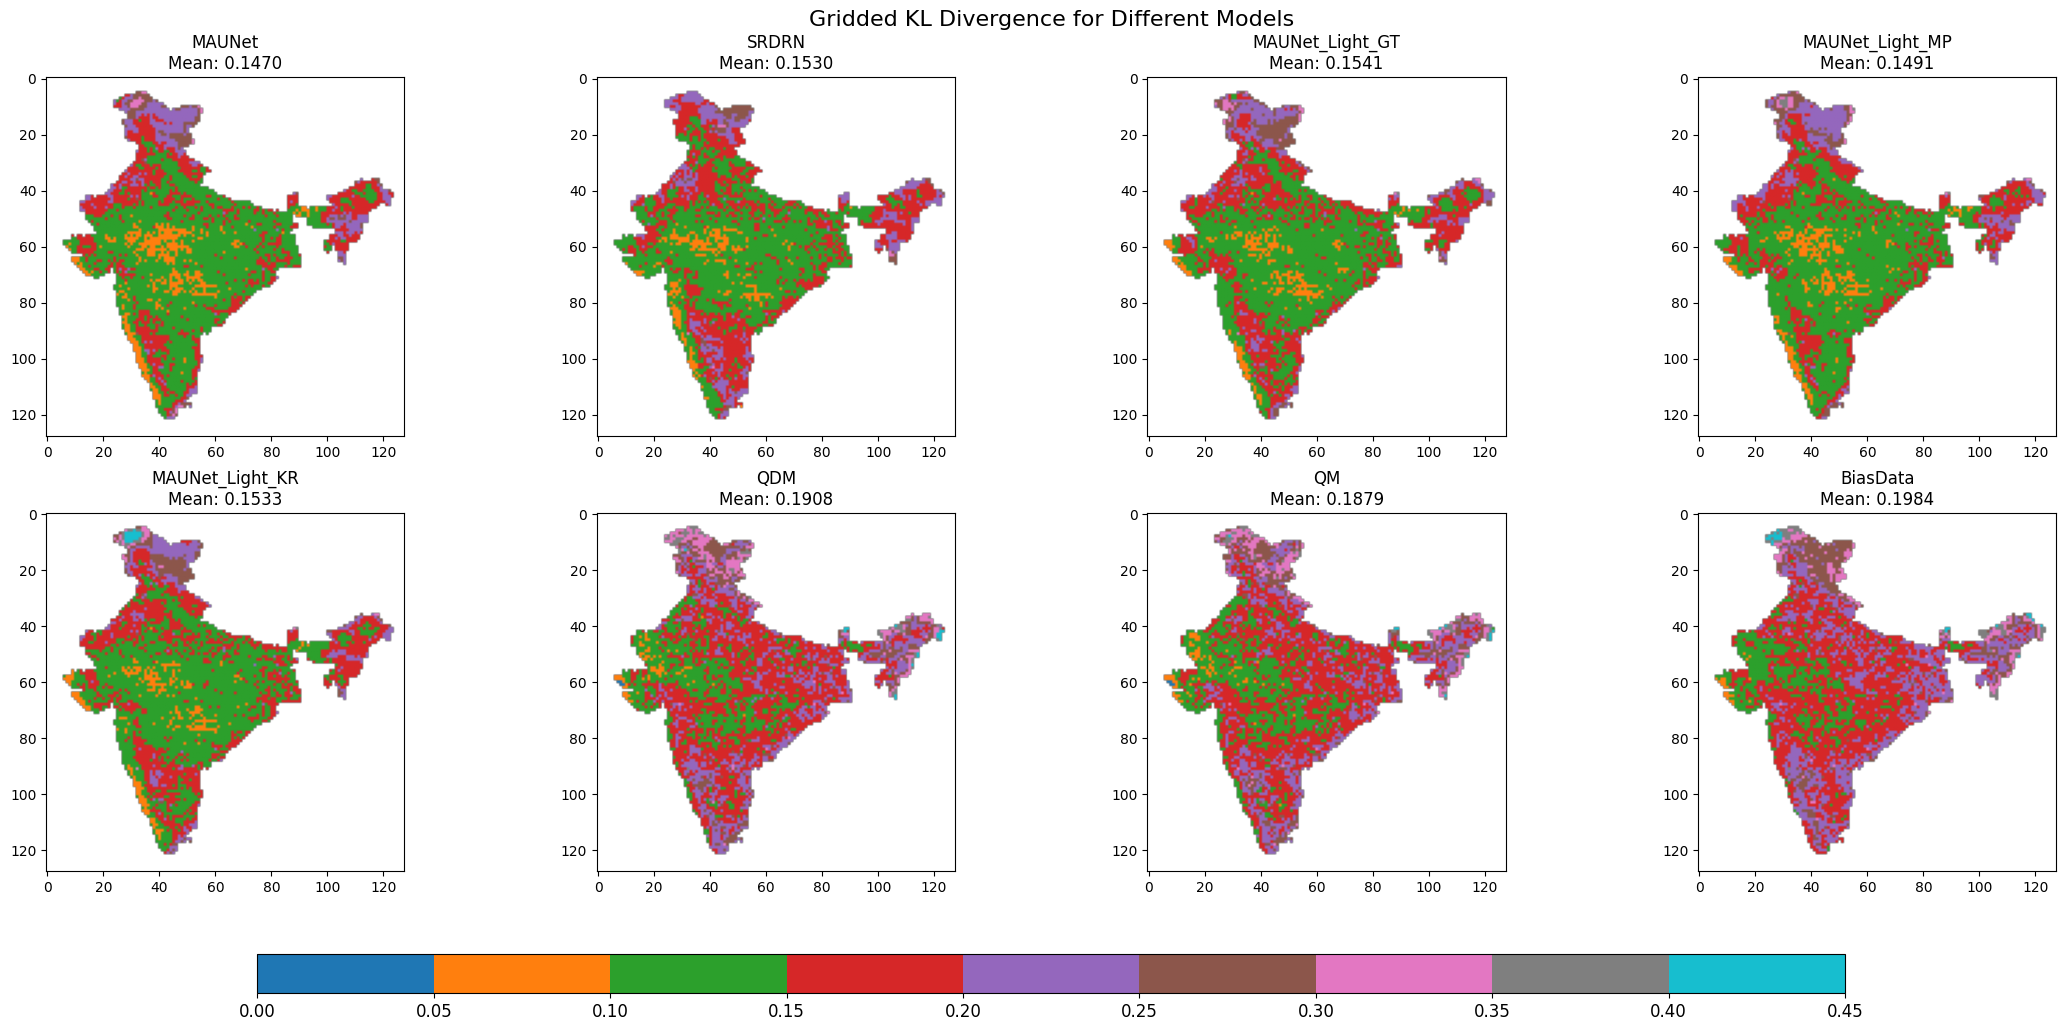

In [ ]:
import matplotlib.pyplot as plt
import matplotlib as mpl
import numpy as np
import numpy.ma as ma

# Dictionary of masked arrays
kl_grids = {
    "MAUNet": Masked_KL_MAUNet_Test_Grid,
    "SRDRN": Masked_KL_SRDRN_Test_Grid,
    "MAUNet_Light_GT": Masked_KL_MAUNet_Light_GT_Test_Grid,
    "MAUNet_Light_MP": Masked_KL_MAUNet_Light_MP_Test_Grid,
    "MAUNet_Light_KR": Masked_KL_MAUNet_Light_KR_Test_Grid,
    "QDM": Masked_KL_QDM_Test_Grid,
    "QM": Masked_KL_QM_Test_Grid,
    "BiasData": Masked_KL_BiasData_Test_Grid
}

# Colormap and normalization
cmap = plt.colormaps["tab10"]
bounds = np.arange(0, 0.5, 0.05)  # From 0 to 1.0 in 0.05 intervals
norm = mpl.colors.BoundaryNorm(bounds, cmap.N)

# Create subplots
fig, axs = plt.subplots(2, 4, figsize=(22, 10), constrained_layout=True)
axs = axs.flatten()

# Plot each model
for i, (model_name, masked_array) in enumerate(kl_grids.items()):
    unmasked_values = masked_array[~masked_array.mask]
    unmasked_values = unmasked_values[~np.isnan(unmasked_values)]
    mean_value = np.mean(unmasked_values)

    im = axs[i].imshow(masked_array, cmap=cmap, norm=norm)
    axs[i].tick_params(axis='x', labelsize=10)
    axs[i].tick_params(axis='y', labelsize=10)
    axs[i].set_title(f"{model_name}\nMean: {mean_value:.4f}", fontsize=12)

# Create colorbar at the bottom
cbar = fig.colorbar(im, ax=axs, orientation='horizontal',
                    fraction=0.05, pad=0.07, aspect=40)
cbar.ax.tick_params(labelsize=12)

# Add a common title
fig.suptitle("Gridded KL Divergence for Different Models", fontsize=16, y=1.02)

plt.show()


#Finding KL Divergence for daily spatial samples

In [ ]:
from scipy.stats import entropy
import statistics
def daily_pdf_cal(Masked_Actual,Masked_Predicted):
  KL_Divergence_daily=[]
  for i in range(len(Masked_Actual)):
    data_act=Masked_Actual[i].compressed()
    data_pred=Masked_Predicted[i].compressed()
    kde_act = gaussian_kde(data_act)
    pdf_values_act = kde_act(data_act)
    kde_pred = gaussian_kde(data_pred)
    pdf_values_pred = kde_pred(data_pred)
    KL_Divergence_daily.append(entropy(pdf_values_act, pdf_values_pred))
  return KL_Divergence_daily

In [ ]:
KL_MAUNet_Test_Daily=daily_pdf_cal(Masked_Label_Test_Grid,Masked_MAUNet_Test_Grid)
KL_SRDRN_Test_Daily=daily_pdf_cal(Masked_Label_Test_Grid,Masked_SRDRN_Test_Grid)
KL_MAUNet_Light_KR_Test_Daily=daily_pdf_cal(Masked_Label_Test_Grid,Masked_MAUNet_Light_KR_Test_Grid)
KL_MAUNet_Light_GT_Test_Daily=daily_pdf_cal(Masked_Label_Test_Grid,Masked_MAUNet_Light_GT_Test_Grid)
KL_MAUNet_Light_MP_Test_Daily=daily_pdf_cal(Masked_Label_Test_Grid,Masked_MAUNet_Light_MP_Test_Grid)
KL_QDM_Test_Daily=daily_pdf_cal(Masked_Label_Test_Grid,Masked_QDM_Test_Grid)
KL_QM_Test_Daily=daily_pdf_cal(Masked_Label_Test_Grid,Masked_QM_Test_Grid)
KL_BiasData_Test_Daily=daily_pdf_cal(Masked_Label_Test_Grid,Masked_BiasData_Test_Grid)

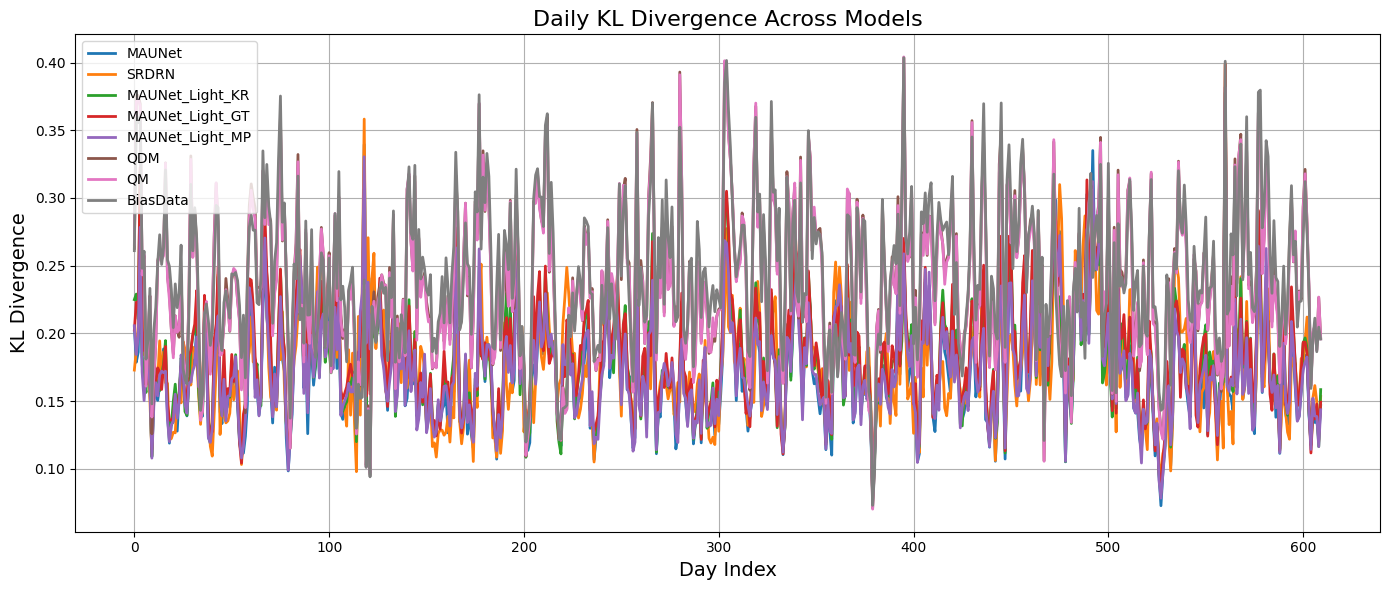

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Convert KL arrays to numpy arrays if not already
KL_MAUNet_Test_Daily         = np.array(KL_MAUNet_Test_Daily)
KL_SRDRN_Test_Daily          = np.array(KL_SRDRN_Test_Daily)
KL_MAUNet_Light_KR_Test_Daily = np.array(KL_MAUNet_Light_KR_Test_Daily)
KL_MAUNet_Light_GT_Test_Daily = np.array(KL_MAUNet_Light_GT_Test_Daily)
KL_MAUNet_Light_MP_Test_Daily = np.array(KL_MAUNet_Light_MP_Test_Daily)
KL_QDM_Test_Daily            = np.array(KL_QDM_Test_Daily)
KL_QM_Test_Daily             = np.array(KL_QM_Test_Daily)
KL_BiasData_Test_Daily       = np.array(KL_BiasData_Test_Daily)

# Generate day indices (x-axis)
days = np.arange(len(KL_MAUNet_Test_Daily))

# Plot each model
plt.figure(figsize=(14, 6))

plt.plot(days, KL_MAUNet_Test_Daily, label='MAUNet', linewidth=2)
plt.plot(days, KL_SRDRN_Test_Daily, label='SRDRN', linewidth=2)
plt.plot(days, KL_MAUNet_Light_KR_Test_Daily, label='MAUNet_Light_KR', linewidth=2)
plt.plot(days, KL_MAUNet_Light_GT_Test_Daily, label='MAUNet_Light_GT', linewidth=2)
plt.plot(days, KL_MAUNet_Light_MP_Test_Daily, label='MAUNet_Light_MP', linewidth=2)
plt.plot(days, KL_QDM_Test_Daily, label='QDM', linewidth=2)
plt.plot(days, KL_QM_Test_Daily, label='QM', linewidth=2)
plt.plot(days, KL_BiasData_Test_Daily, label='BiasData', linewidth=2)

# Formatting
plt.xlabel('Day Index', fontsize=14)
plt.ylabel('KL Divergence', fontsize=14)
plt.title('Daily KL Divergence Across Models', fontsize=16)
plt.legend(fontsize=10)
plt.grid(True)
plt.tight_layout()

plt.show()


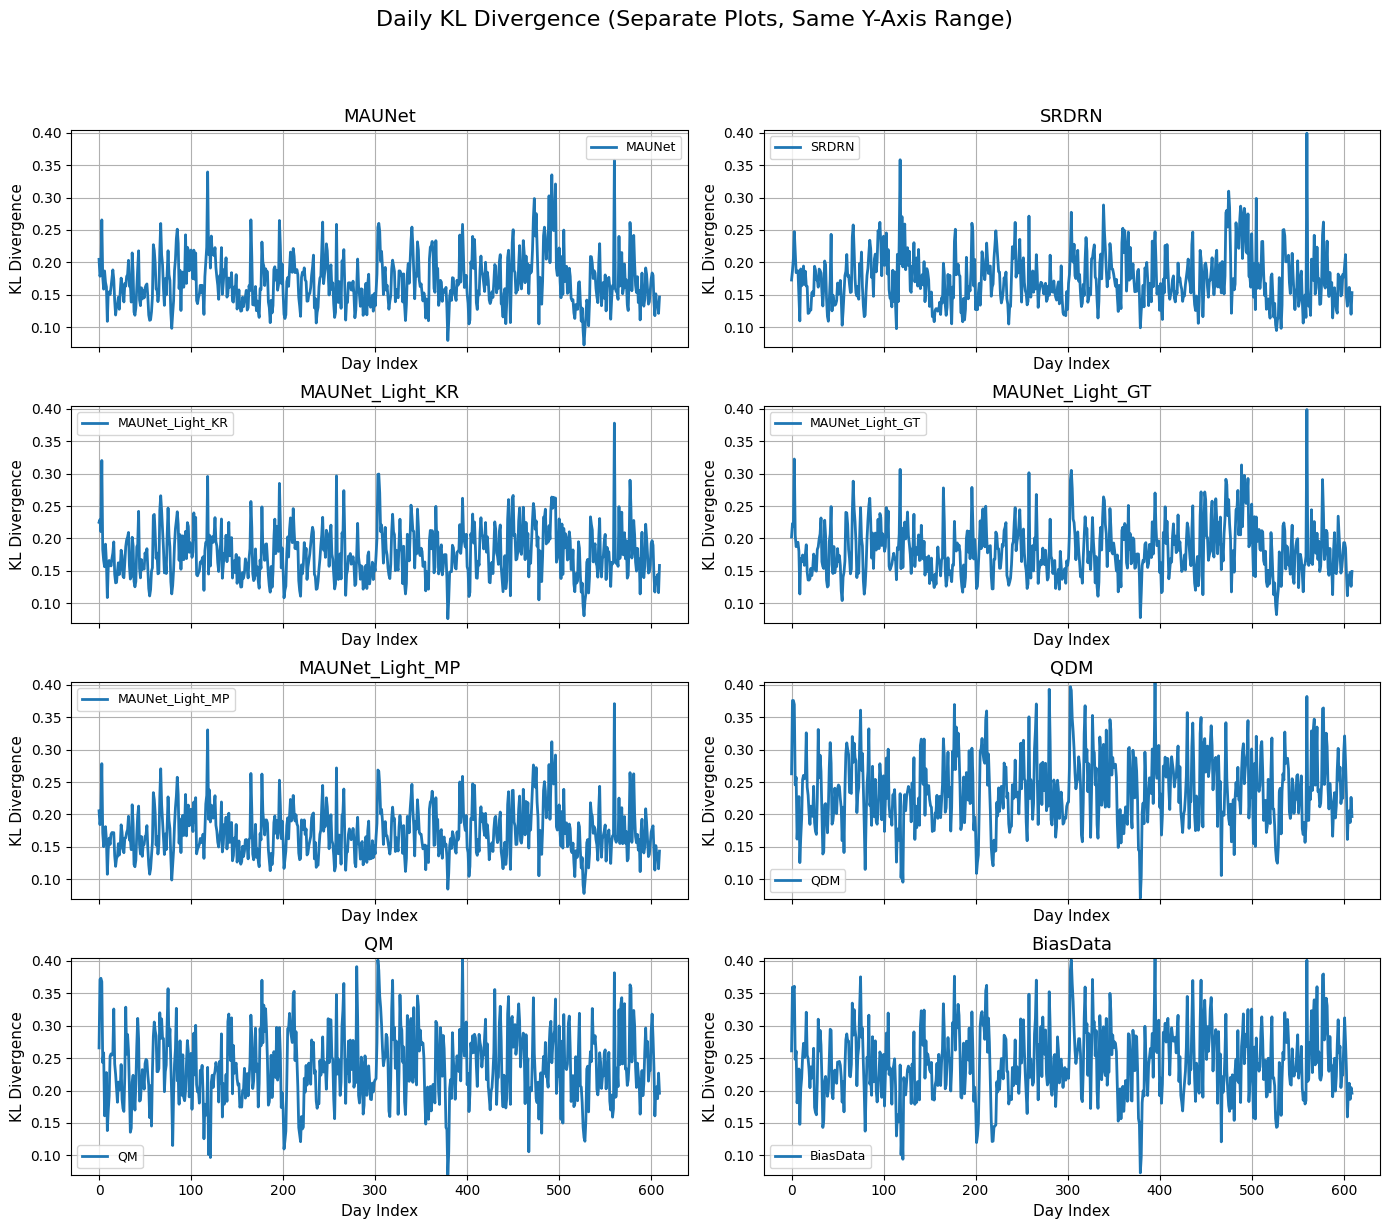

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Convert to numpy arrays (if not already)
KL_MAUNet_Test_Daily          = np.array(KL_MAUNet_Test_Daily)
KL_SRDRN_Test_Daily           = np.array(KL_SRDRN_Test_Daily)
KL_MAUNet_Light_KR_Test_Daily = np.array(KL_MAUNet_Light_KR_Test_Daily)
KL_MAUNet_Light_GT_Test_Daily = np.array(KL_MAUNet_Light_GT_Test_Daily)
KL_MAUNet_Light_MP_Test_Daily = np.array(KL_MAUNet_Light_MP_Test_Daily)
KL_QDM_Test_Daily             = np.array(KL_QDM_Test_Daily)
KL_QM_Test_Daily              = np.array(KL_QM_Test_Daily)
KL_BiasData_Test_Daily        = np.array(KL_BiasData_Test_Daily)

# Model dictionary
models = {
    'MAUNet': KL_MAUNet_Test_Daily,
    'SRDRN': KL_SRDRN_Test_Daily,
    'MAUNet_Light_KR': KL_MAUNet_Light_KR_Test_Daily,
    'MAUNet_Light_GT': KL_MAUNet_Light_GT_Test_Daily,
    'MAUNet_Light_MP': KL_MAUNet_Light_MP_Test_Daily,
    'QDM': KL_QDM_Test_Daily,
    'QM': KL_QM_Test_Daily,
    'BiasData': KL_BiasData_Test_Daily
}

# Compute global min and max for y-axis
all_values = np.concatenate(list(models.values()))
y_min = np.min(all_values)
y_max = np.max(all_values)

# Subplot layout
n_models = len(models)
cols = 2
rows = (n_models + 1) // cols

# Create subplots
fig, axs = plt.subplots(rows, cols, figsize=(14, 3 * rows), sharex=True)
axs = axs.flatten()

# Plot each model in a separate subplot
for i, (model_name, kl_values) in enumerate(models.items()):
    days = np.arange(len(kl_values))
    axs[i].plot(days, kl_values, label=model_name, color='tab:blue', linewidth=2)
    axs[i].set_title(model_name, fontsize=13)
    axs[i].set_ylabel("KL Divergence", fontsize=11)
    axs[i].set_ylim(y_min, y_max)  # <-- Uniform y-axis range
    axs[i].grid(True)
    axs[i].legend(fontsize=9)

# Set shared x-labels
for ax in axs:
    ax.set_xlabel("Day Index", fontsize=11)

# Hide unused subplots
for j in range(i + 1, len(axs)):
    fig.delaxes(axs[j])

plt.tight_layout()
plt.suptitle("Daily KL Divergence (Separate Plots, Same Y-Axis Range)", fontsize=16, y=1.02)
plt.subplots_adjust(top=0.92)
plt.show()


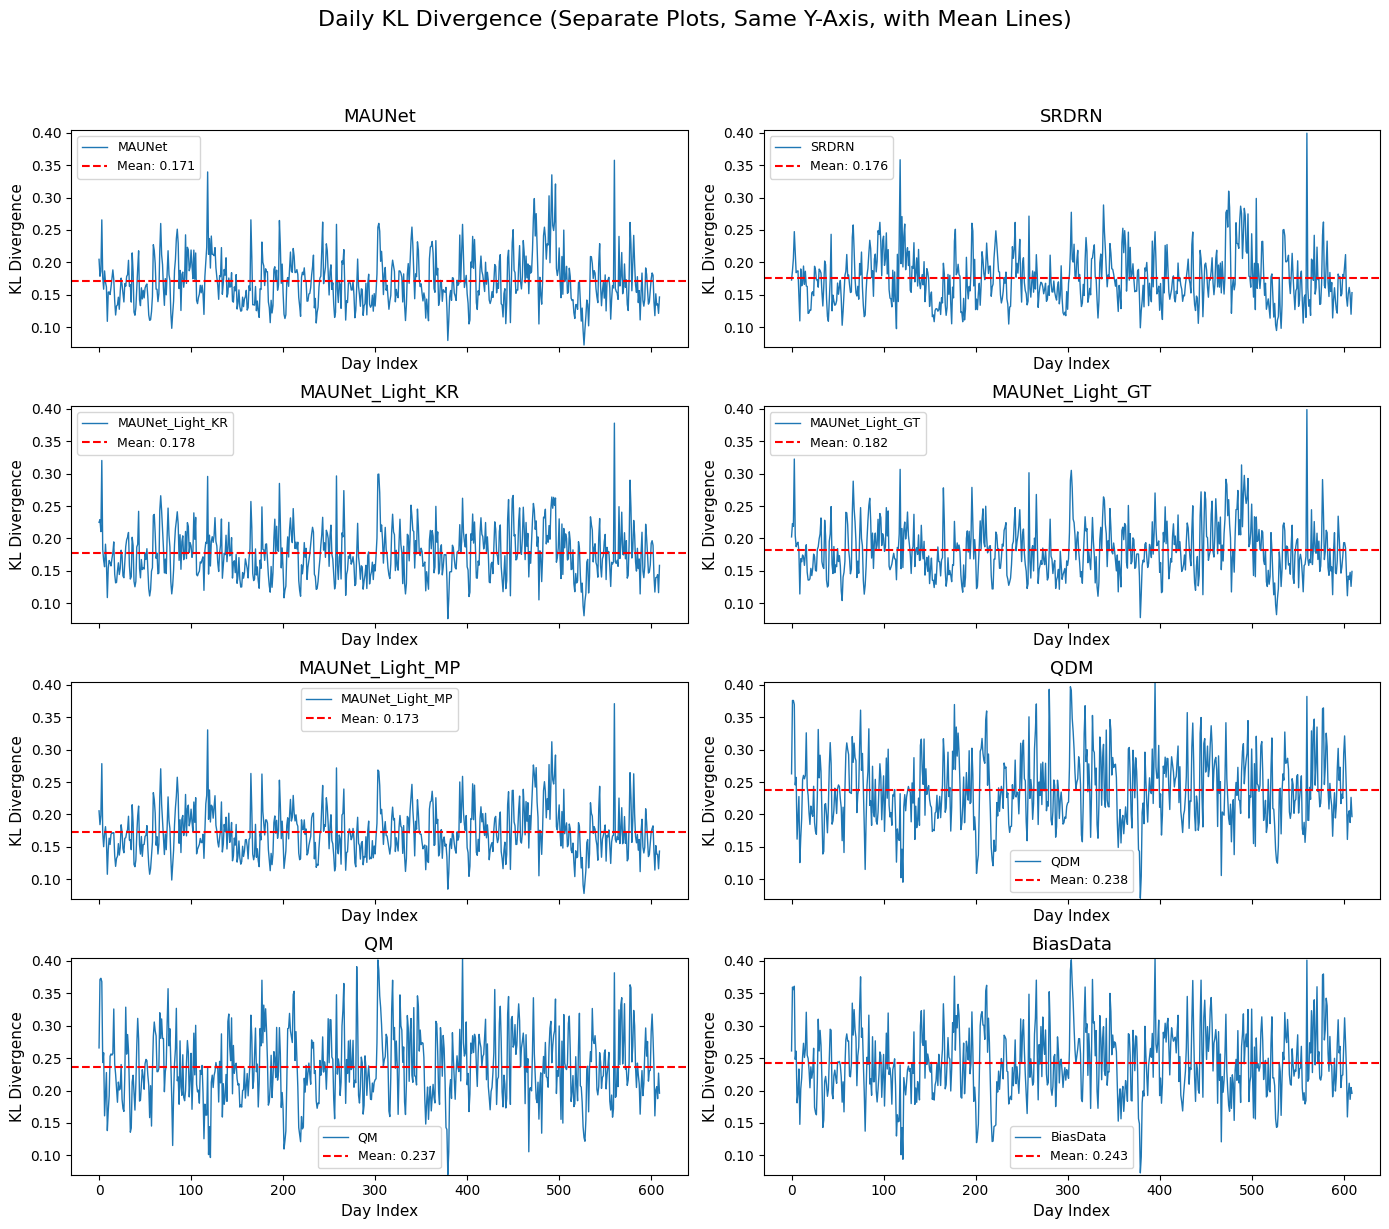

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Convert to numpy arrays (if not already)
KL_MAUNet_Test_Daily          = np.array(KL_MAUNet_Test_Daily)
KL_SRDRN_Test_Daily           = np.array(KL_SRDRN_Test_Daily)
KL_MAUNet_Light_KR_Test_Daily = np.array(KL_MAUNet_Light_KR_Test_Daily)
KL_MAUNet_Light_GT_Test_Daily = np.array(KL_MAUNet_Light_GT_Test_Daily)
KL_MAUNet_Light_MP_Test_Daily = np.array(KL_MAUNet_Light_MP_Test_Daily)
KL_QDM_Test_Daily             = np.array(KL_QDM_Test_Daily)
KL_QM_Test_Daily              = np.array(KL_QM_Test_Daily)
KL_BiasData_Test_Daily        = np.array(KL_BiasData_Test_Daily)

# Model dictionary
models = {
    'MAUNet': KL_MAUNet_Test_Daily,
    'SRDRN': KL_SRDRN_Test_Daily,
    'MAUNet_Light_KR': KL_MAUNet_Light_KR_Test_Daily,
    'MAUNet_Light_GT': KL_MAUNet_Light_GT_Test_Daily,
    'MAUNet_Light_MP': KL_MAUNet_Light_MP_Test_Daily,
    'QDM': KL_QDM_Test_Daily,
    'QM': KL_QM_Test_Daily,
    'BiasData': KL_BiasData_Test_Daily
}

# Compute global min and max for y-axis
all_values = np.concatenate(list(models.values()))
y_min = np.min(all_values)
y_max = np.max(all_values)

# Subplot layout
n_models = len(models)
cols = 2
rows = (n_models + 1) // cols

# Create subplots
fig, axs = plt.subplots(rows, cols, figsize=(14, 3 * rows), sharex=True)
axs = axs.flatten()

# Plot each model in a separate subplot
for i, (model_name, kl_values) in enumerate(models.items()):
    days = np.arange(len(kl_values))
    mean_val = np.mean(kl_values)

    axs[i].plot(days, kl_values, label=model_name, color='tab:blue', linewidth=1)
    axs[i].axhline(y=mean_val, color='red', linestyle='--', linewidth=1.5, label=f'Mean: {mean_val:.3f}')

    axs[i].set_title(model_name, fontsize=13)
    axs[i].set_ylabel("KL Divergence", fontsize=11)
    axs[i].set_ylim(y_min, y_max)
    #axs[i].grid(True)
    axs[i].legend(fontsize=9)

# Set shared x-labels
for ax in axs:
    ax.set_xlabel("Day Index", fontsize=11)

# Hide unused subplots
for j in range(i + 1, len(axs)):
    fig.delaxes(axs[j])

plt.tight_layout()
plt.suptitle("Daily KL Divergence (Separate Plots, Same Y-Axis, with Mean Lines)", fontsize=16, y=1.02)
plt.subplots_adjust(top=0.92)
plt.show()
